# Diving deep into batting within Baseball
## Authors: Adan Hernandez & Isaiah Dawkins

### Dataset Identification and Acquisition
For this project, we have selected a dataset containing Major League Baseball (MLB) batting statistics for all players during the 2024 and 2025 seasons. Baseball is a data-rich sport, and batting statistics offer numerous insights into player performance, league-wide trends, and team strategies. 

The dataset includes player-level stats such a:
- **Player information**: name, age, team, position, and handedness (where applicable)
- **Batting performance metrics**: games played (G), at-bats (AB), hits (H), doubles (2B), triples (3B), home runs (HR), runs batted in (RBI), walks (BB), strikeouts (SO), batting average (AVG), on-base percentage (OBP), slugging percentage (SLG), on-base plus slugging (OPS), and much more
- **Seasonal contex**t: year (will be added), team, and league (AL/NL)

The dataset was downloaded as CSV files — one for each season (2024 and 2025). Each file contains one row per player per season, including both qualified hitters and those with limited plate appearances.

### Questions Posed

**Questions that we aim to answer with our data analysis throughout this project:**

1. **Seasonal Comparison**:
   - How did overall league batting performance (e.g., AVG, HR, OPS) differ between 2024 and 2025?
2. **Perfomance Deltas**:
   - Which 10 players showed the largest improvement in offensive stats? Which 10 players should the largest decline in offensive stats?
3. **Power vs. Contact**:
   - Is there a clear tradeoff between power hitters (HR leaders) and batting average consistency?
4. **Team-Level Analysis**:
   - Which teams had the most productive lineups, and how did their team batting stats correlate with win totals?
5. **Player Efficiency**:
   - Are high on-base percentages (OBP) more strongly correlated with runs scored (R) or RBIs?

## Data Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Importing our Data Sets

In [2]:
batting_25_df = pd.read_csv('./Batting_2025.csv')
batting_25_df.head(10)

,Rk,Player,Age,Team,Lg,WAR,G,PA,AB,R,...,Rbat+,TB,GIDP,HBP,SH,SF,IBB,Pos,Awards,Player-additional
0,1,Francisco Lindor#,31,NYM,NL,5.8,160,732,644,117,...,128.0,300,9,16,0,7,2,*6/DH,AS,lindofr01
1,2,Rafael Devers*,28,2TM,2LG,4.0,163,729,607,99,...,139.0,291,16,6,0,4,10,*D3/5H,NaN,deverra01
2,2,Rafael Devers*,28,BOS,AL,2.3,73,334,272,47,...,153.0,137,7,4,0,2,7,D,NaN,deverra01
3,2,Rafael Devers*,28,SFG,NL,1.8,90,395,335,52,...,127.0,154,9,2,0,2,3,D3/5H,NaN,deverra01
4,3,Shohei Ohtani*,30,LAD,NL,6.6,158,727,611,146,...,175.0,380,9,3,0,2,20,*D1,AS,ohtansh01
5,4,Matt Olson*,31,ATL,NL,6.1,162,724,624,98,...,136.0,302,14,4,0,5,2,*3,AS,olsonma02
6,5,Kyle Schwarber*,32,PHI,NL,4.7,162,724,604,111,...,149.0,340,4,11,0,1,6,*D/7,AS,schwaky01
7,6,Geraldo Perdomo#,25,ARI,NL,7.0,161,720,597,98,...,139.0,276,11,10,8,11,1,*6/H,NaN,perdoge01
8,7,Juan Soto*,26,NYM,NL,6.2,160,715,577,120,...,163.0,303,17,3,1,6,13,*9/D,NaN,sotoju01
9,8,Julio Rodríguez,24,SEA,AL,6.8,160,710,652,106,...,133.0,309,15,12,0,2,5,*8/DH,AS,rodriju01


In [3]:
batting_24_df = pd.read_csv('./Batting_2024.csv')
batting_24_df.head(10)

,Rk,Player,Age,Team,Lg,WAR,G,PA,AB,R,...,Rbat+,TB,GIDP,HBP,SH,SF,IBB,Pos,Awards,Player-additional
0,1,Jarren Duran*,27,BOS,AL,8.7,160,735,671,111,...,134.0,330,6,6,1,3,1,*87,ASMVP-8,duranja01
1,2,Shohei Ohtani*,29,LAD,NL,9.2,159,731,636,134,...,190.0,411,7,6,0,5,10,*D,ASMVP-1SS,ohtansh01
2,3,Gunnar Henderson*,23,BAL,AL,9.1,159,719,630,118,...,157.0,333,2,7,0,4,1,*6/D,ASMVP-4,hendegu01
3,4,Marcus Semien,33,TEX,AL,4.1,159,718,650,101,...,100.0,254,9,3,0,1,2,*4,AS,semiema01
4,5,Juan Soto*,25,NYY,AL,7.9,157,713,576,128,...,179.0,328,10,4,0,4,2,*9/7DH,ASMVP-3SS,sotoju01
5,6,Bobby Witt Jr.,24,KCR,AL,9.4,161,709,636,125,...,171.0,374,4,8,0,8,9,*6/D,ASMVP-2GGSS,wittbo02
6,7,Aaron Judge,32,NYY,AL,10.8,158,704,559,122,...,223.0,392,22,9,0,2,20,*8D/97,ASMVP-1SS,judgeaa01
7,8,Vladimir Guerrero Jr.,25,TOR,AL,6.2,159,697,616,98,...,165.0,335,16,5,0,4,12,*3D5/H,ASMVP-6SS,guerrvl02
8,9,Elly De La Cruz#,22,CIN,NL,5.2,160,696,618,105,...,122.0,291,12,6,2,1,2,*6/H,ASMVP-8,delacel01
9,10,Pete Alonso,29,NYM,NL,2.6,162,695,608,91,...,122.0,279,14,13,0,4,4,*3/DH,AS,alonspe01


### Combine our data into one CSV/dataset
#### Step 0.) Combine our two data sets from 2024 & 2025 to make a larger single data set for ease of use and cleaning process

In [4]:
# Add column to our tables
batting_24_df['Year'] = "2024"
batting_25_df['Year'] = "2025"

# Concat the two csv's and save it
batting_data_df = pd.concat([batting_24_df, batting_25_df], ignore_index=True)
batting_data_df.to_csv('batting_data_24_25.csv', index=False)

# Sanity check to make sure we have one dataset
batting_data_df.head(10)

,Rk,Player,Age,Team,Lg,WAR,G,PA,AB,R,...,TB,GIDP,HBP,SH,SF,IBB,Pos,Awards,Player-additional,Year
0,1,Jarren Duran*,27,BOS,AL,8.7,160,735,671,111,...,330,6,6,1,3,1,*87,ASMVP-8,duranja01,2024
1,2,Shohei Ohtani*,29,LAD,NL,9.2,159,731,636,134,...,411,7,6,0,5,10,*D,ASMVP-1SS,ohtansh01,2024
2,3,Gunnar Henderson*,23,BAL,AL,9.1,159,719,630,118,...,333,2,7,0,4,1,*6/D,ASMVP-4,hendegu01,2024
3,4,Marcus Semien,33,TEX,AL,4.1,159,718,650,101,...,254,9,3,0,1,2,*4,AS,semiema01,2024
4,5,Juan Soto*,25,NYY,AL,7.9,157,713,576,128,...,328,10,4,0,4,2,*9/7DH,ASMVP-3SS,sotoju01,2024
5,6,Bobby Witt Jr.,24,KCR,AL,9.4,161,709,636,125,...,374,4,8,0,8,9,*6/D,ASMVP-2GGSS,wittbo02,2024
6,7,Aaron Judge,32,NYY,AL,10.8,158,704,559,122,...,392,22,9,0,2,20,*8D/97,ASMVP-1SS,judgeaa01,2024
7,8,Vladimir Guerrero Jr.,25,TOR,AL,6.2,159,697,616,98,...,335,16,5,0,4,12,*3D5/H,ASMVP-6SS,guerrvl02,2024
8,9,Elly De La Cruz#,22,CIN,NL,5.2,160,696,618,105,...,291,12,6,2,1,2,*6/H,ASMVP-8,delacel01,2024
9,10,Pete Alonso,29,NYM,NL,2.6,162,695,608,91,...,279,14,13,0,4,4,*3/DH,AS,alonspe01,2024


### Data Cleaning and Preparation

#### Step 1.) Add a column for handedness, map handedness values. 
##### Our data was imported with characters alongside Player names, indicating batter handedness. 
##### * is left handed, # both handedness, nothing is right handed, ? is unknown

In [5]:
# Add column for handedness
batting_data_df['Handedness'] = "Right"

# Masks for checking the handedness, as shown on the Player name before cleaning
left_mask = batting_data_df['Player'].str.contains('*', regex=False)
both_mask = batting_data_df['Player'].str.contains('#', regex=False)
unknown_mask = batting_data_df['Player'].str.contains('?', regex=False)

# Set the appropriate handedness after we parse for each type
batting_data_df.loc[left_mask, 'Handedness'] = 'Left'
batting_data_df.loc[both_mask, 'Handedness'] = 'Both'
batting_data_df.loc[unknown_mask, 'Handedness'] = 'Unknown'

batting_data_df.head(10)

,Rk,Player,Age,Team,Lg,WAR,G,PA,AB,R,...,GIDP,HBP,SH,SF,IBB,Pos,Awards,Player-additional,Year,Handedness
0,1,Jarren Duran*,27,BOS,AL,8.7,160,735,671,111,...,6,6,1,3,1,*87,ASMVP-8,duranja01,2024,Left
1,2,Shohei Ohtani*,29,LAD,NL,9.2,159,731,636,134,...,7,6,0,5,10,*D,ASMVP-1SS,ohtansh01,2024,Left
2,3,Gunnar Henderson*,23,BAL,AL,9.1,159,719,630,118,...,2,7,0,4,1,*6/D,ASMVP-4,hendegu01,2024,Left
3,4,Marcus Semien,33,TEX,AL,4.1,159,718,650,101,...,9,3,0,1,2,*4,AS,semiema01,2024,Right
4,5,Juan Soto*,25,NYY,AL,7.9,157,713,576,128,...,10,4,0,4,2,*9/7DH,ASMVP-3SS,sotoju01,2024,Left
5,6,Bobby Witt Jr.,24,KCR,AL,9.4,161,709,636,125,...,4,8,0,8,9,*6/D,ASMVP-2GGSS,wittbo02,2024,Right
6,7,Aaron Judge,32,NYY,AL,10.8,158,704,559,122,...,22,9,0,2,20,*8D/97,ASMVP-1SS,judgeaa01,2024,Right
7,8,Vladimir Guerrero Jr.,25,TOR,AL,6.2,159,697,616,98,...,16,5,0,4,12,*3D5/H,ASMVP-6SS,guerrvl02,2024,Right
8,9,Elly De La Cruz#,22,CIN,NL,5.2,160,696,618,105,...,12,6,2,1,2,*6/H,ASMVP-8,delacel01,2024,Both
9,10,Pete Alonso,29,NYM,NL,2.6,162,695,608,91,...,14,13,0,4,4,*3/DH,AS,alonspe01,2024,Right


#### Step 2.) Remove flags that were added to Player names
Since the flags have been properly mapped to the correct values in the Handedness column, we want to remove these characters

In [6]:
batting_data_df.loc[left_mask, 'Player'] = batting_data_df['Player'].str[:-1]
batting_data_df.loc[both_mask, 'Player'] = batting_data_df['Player'].str[:-1]
batting_data_df.loc[unknown_mask, 'Player'] = batting_data_df['Player'].str[:-1]

batting_data_df.head(10)

,Rk,Player,Age,Team,Lg,WAR,G,PA,AB,R,...,GIDP,HBP,SH,SF,IBB,Pos,Awards,Player-additional,Year,Handedness
0,1,Jarren Duran,27,BOS,AL,8.7,160,735,671,111,...,6,6,1,3,1,*87,ASMVP-8,duranja01,2024,Left
1,2,Shohei Ohtani,29,LAD,NL,9.2,159,731,636,134,...,7,6,0,5,10,*D,ASMVP-1SS,ohtansh01,2024,Left
2,3,Gunnar Henderson,23,BAL,AL,9.1,159,719,630,118,...,2,7,0,4,1,*6/D,ASMVP-4,hendegu01,2024,Left
3,4,Marcus Semien,33,TEX,AL,4.1,159,718,650,101,...,9,3,0,1,2,*4,AS,semiema01,2024,Right
4,5,Juan Soto,25,NYY,AL,7.9,157,713,576,128,...,10,4,0,4,2,*9/7DH,ASMVP-3SS,sotoju01,2024,Left
5,6,Bobby Witt Jr.,24,KCR,AL,9.4,161,709,636,125,...,4,8,0,8,9,*6/D,ASMVP-2GGSS,wittbo02,2024,Right
6,7,Aaron Judge,32,NYY,AL,10.8,158,704,559,122,...,22,9,0,2,20,*8D/97,ASMVP-1SS,judgeaa01,2024,Right
7,8,Vladimir Guerrero Jr.,25,TOR,AL,6.2,159,697,616,98,...,16,5,0,4,12,*3D5/H,ASMVP-6SS,guerrvl02,2024,Right
8,9,Elly De La Cruz,22,CIN,NL,5.2,160,696,618,105,...,12,6,2,1,2,*6/H,ASMVP-8,delacel01,2024,Both
9,10,Pete Alonso,29,NYM,NL,2.6,162,695,608,91,...,14,13,0,4,4,*3/DH,AS,alonspe01,2024,Right


#### We must do the same for the Pos column

In [7]:
# Reassigning the masks to check for special characters in the Pos column
left_mask = batting_data_df['Pos'].str.contains('*', regex=False)
both_mask = batting_data_df['Pos'].str.contains('#', regex=False)
unknown_mask = batting_data_df['Pos'].str.contains('?', regex=False)

# Removing the special characters in the Pos column
batting_data_df.loc[left_mask, 'Pos'] = batting_data_df['Pos'].str.replace('*', '', regex=False)
batting_data_df.loc[both_mask, 'Pos'] = batting_data_df['Pos'].str.replace('#', '', regex=False)
batting_data_df.loc[unknown_mask, 'Pos'] = batting_data_df['Pos'].str.replace('?', '', regex=False)

batting_data_df.head(10)

,Rk,Player,Age,Team,Lg,WAR,G,PA,AB,R,...,GIDP,HBP,SH,SF,IBB,Pos,Awards,Player-additional,Year,Handedness
0,1,Jarren Duran,27,BOS,AL,8.7,160,735,671,111,...,6,6,1,3,1,87,ASMVP-8,duranja01,2024,Left
1,2,Shohei Ohtani,29,LAD,NL,9.2,159,731,636,134,...,7,6,0,5,10,D,ASMVP-1SS,ohtansh01,2024,Left
2,3,Gunnar Henderson,23,BAL,AL,9.1,159,719,630,118,...,2,7,0,4,1,6/D,ASMVP-4,hendegu01,2024,Left
3,4,Marcus Semien,33,TEX,AL,4.1,159,718,650,101,...,9,3,0,1,2,4,AS,semiema01,2024,Right
4,5,Juan Soto,25,NYY,AL,7.9,157,713,576,128,...,10,4,0,4,2,9/7DH,ASMVP-3SS,sotoju01,2024,Left
5,6,Bobby Witt Jr.,24,KCR,AL,9.4,161,709,636,125,...,4,8,0,8,9,6/D,ASMVP-2GGSS,wittbo02,2024,Right
6,7,Aaron Judge,32,NYY,AL,10.8,158,704,559,122,...,22,9,0,2,20,8D/97,ASMVP-1SS,judgeaa01,2024,Right
7,8,Vladimir Guerrero Jr.,25,TOR,AL,6.2,159,697,616,98,...,16,5,0,4,12,3D5/H,ASMVP-6SS,guerrvl02,2024,Right
8,9,Elly De La Cruz,22,CIN,NL,5.2,160,696,618,105,...,12,6,2,1,2,6/H,ASMVP-8,delacel01,2024,Both
9,10,Pete Alonso,29,NYM,NL,2.6,162,695,608,91,...,14,13,0,4,4,3/DH,AS,alonspe01,2024,Right


#### Step 3.) Check the info of the data frame for any null values

In [8]:
batting_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1817 entries, 0 to 1816
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rk                 1817 non-null   int64  
 1   Player             1817 non-null   object 
 2   Age                1817 non-null   int64  
 3   Team               1817 non-null   object 
 4   Lg                 1817 non-null   object 
 5   WAR                1815 non-null   float64
 6   G                  1817 non-null   int64  
 7   PA                 1817 non-null   int64  
 8   AB                 1817 non-null   int64  
 9   R                  1817 non-null   int64  
 10  H                  1817 non-null   int64  
 11  2B                 1817 non-null   int64  
 12  3B                 1817 non-null   int64  
 13  HR                 1817 non-null   int64  
 14  RBI                1817 non-null   int64  
 15  SB                 1817 non-null   int64  
 16  CS                 1817 

#### The Awards column seems to have a considerable amount of NULL values.
#### We will first analyze the column to have a better understanding of how to handle the NULL values.

In [9]:
batting_data_df['Awards'].head(30)

0         ASMVP-8
1       ASMVP-1SS
2         ASMVP-4
3              AS
4       ASMVP-3SS
5     ASMVP-2GGSS
6       ASMVP-1SS
7       ASMVP-6SS
8         ASMVP-8
9              AS
10       MVP-19GG
11             AS
12         MVP-15
13        MVP-2SS
14            NaN
15         MVP-10
16        ASMVP-4
17            NaN
18            NaN
19     ASMVP-15SS
20      ASMVP-5SS
21      ASMVP-5SS
22       ASMVP-18
23            NaN
24            NaN
25     ASMVP-14SS
26     ASMVP-14SS
27            NaN
28            NaN
29            NaN
Name: Awards, dtype: object

#### The Awards column lists any awards the player has won for the season.
#### We can treat the NULL values as having no awards and use fillna() to convert the NULL types to 'None'.

In [10]:
batting_data_df = batting_data_df.fillna({'Awards': 'None'})

batting_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1817 entries, 0 to 1816
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rk                 1817 non-null   int64  
 1   Player             1817 non-null   object 
 2   Age                1817 non-null   int64  
 3   Team               1817 non-null   object 
 4   Lg                 1817 non-null   object 
 5   WAR                1815 non-null   float64
 6   G                  1817 non-null   int64  
 7   PA                 1817 non-null   int64  
 8   AB                 1817 non-null   int64  
 9   R                  1817 non-null   int64  
 10  H                  1817 non-null   int64  
 11  2B                 1817 non-null   int64  
 12  3B                 1817 non-null   int64  
 13  HR                 1817 non-null   int64  
 14  RBI                1817 non-null   int64  
 15  SB                 1817 non-null   int64  
 16  CS                 1817 

#### The awards column has no null values now.
#### Columns BA, OBP, SLG, OPS, OPS+, rOBA, and Rbat+ have roughly 180 NULL values

We will first analyze the data we get from these rows containing null values. We will be looking at the those columns as well as the AB (at-bats) column to see if those players have any data to provide in the first place.

In [11]:
# Creating a mask to find all the null values in BA column
ba_null_mask = batting_data_df['BA'].isnull()

# Creating a list to indicate columns to select in next step
na_cols = ['AB','BA', 'OBP', 'SLG', 'OPS', 'OPS+', 'rOBA', 'Rbat+']

# Selecting all the rows with null values in BA
ba_null_df = batting_data_df[ba_null_mask]

ba_null_df[na_cols].head(30)

,AB,BA,OBP,SLG,OPS,OPS+,rOBA,Rbat+
636,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
716,0,NaN,1.0,NaN,NaN,NaN,0.691,373.0
803,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
804,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
805,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
806,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
807,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
808,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
809,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
810,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Since the rows that have null values in these columns signify players that had zero at-bats, we can drop them from the data.

In [12]:
batting_data_df = batting_data_df.dropna()

batting_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1629 entries, 0 to 1726
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rk                 1629 non-null   int64  
 1   Player             1629 non-null   object 
 2   Age                1629 non-null   int64  
 3   Team               1629 non-null   object 
 4   Lg                 1629 non-null   object 
 5   WAR                1629 non-null   float64
 6   G                  1629 non-null   int64  
 7   PA                 1629 non-null   int64  
 8   AB                 1629 non-null   int64  
 9   R                  1629 non-null   int64  
 10  H                  1629 non-null   int64  
 11  2B                 1629 non-null   int64  
 12  3B                 1629 non-null   int64  
 13  HR                 1629 non-null   int64  
 14  RBI                1629 non-null   int64  
 15  SB                 1629 non-null   int64  
 16  CS                 1629 non-n

#### We now have a data frame of 1629 rows, with no null values, correct data types, and cleaned values without special characters

In [13]:
batting_data_df

,Rk,Player,Age,Team,Lg,WAR,G,PA,AB,R,...,GIDP,HBP,SH,SF,IBB,Pos,Awards,Player-additional,Year,Handedness
0,1,Jarren Duran,27,BOS,AL,8.7,160,735,671,111,...,6,6,1,3,1,87,ASMVP-8,duranja01,2024,Left
1,2,Shohei Ohtani,29,LAD,NL,9.2,159,731,636,134,...,7,6,0,5,10,D,ASMVP-1SS,ohtansh01,2024,Left
2,3,Gunnar Henderson,23,BAL,AL,9.1,159,719,630,118,...,2,7,0,4,1,6/D,ASMVP-4,hendegu01,2024,Left
3,4,Marcus Semien,33,TEX,AL,4.1,159,718,650,101,...,9,3,0,1,2,4,AS,semiema01,2024,Right
4,5,Juan Soto,25,NYY,AL,7.9,157,713,576,128,...,10,4,0,4,2,9/7DH,ASMVP-3SS,sotoju01,2024,Left
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1722,669,Ryne Nelson,27,ARI,NL,0.1,1,1,1,1,...,0,0,0,0,0,1/H,None,nelsory01,2025,Right
1723,670,Shinnosuke Ogasawara,27,WSN,NL,0.0,1,1,1,0,...,0,0,0,0,0,1,None,ogasash01,2025,Left
1724,671,Colin Rea,34,CHC,NL,0.0,1,1,1,0,...,0,0,0,0,0,1,None,reaco01,2025,Right
1725,672,Garrett Stubbs,32,PHI,NL,0.0,5,1,1,2,...,0,0,0,0,0,/DH2,None,stubbga01,2025,Left


#### Step 4.) Convert Year data type to int for parsing
We need this value to be parsable when we filter, otherwise when using the Year as a filter it will return NaN

In [14]:
batting_data_df["Year"] = batting_data_df["Year"].astype(int)

## Data Visualization

### Overall Summary Statistics and Correlations

Approach:
Before exploring specific research questions, it’s essential to understand the overall structure and distribution of the dataset. This step provides a quantitative overview of the league’s batting performance across all players and both seasons combined.

We will:
1. Select key offensive performance metrics to summarize.
2. Calculate basic descriptive statistics — mean, median, and standard deviation.
3. Generate a correlation matrix to examine how different batting metrics relate to one another.
4. Visualize the relationships with a heatmap for easier interpretation.

#### Step 1: Select key batting performance metrics for summary statistics

In [15]:
metrics = ["BA", "OBP", "SLG", "OPS", "R", "RBI", "HR", "SO", "BB"]

#### Step 2: Calculate mean, median, and standard deviation for each metric

In [16]:
summary_stats = pd.DataFrame({
    "Mean": batting_data_df[metrics].mean().round(3),
    "Median": batting_data_df[metrics].median().round(3),
    "Std Dev": batting_data_df[metrics].std().round(3)
})

# Display summary statistics
summary_stats

,Mean,Median,Std Dev
BA,0.218,0.229,0.083
OBP,0.285,0.296,0.088
SLG,0.343,0.360,0.135
OPS,0.628,0.654,0.211
R,28.926,19.000,27.979
RBI,27.641,18.000,27.933
HR,7.403,4.000,9.121
SO,55.783,43.000,47.505
BB,20.539,13.000,21.201


#### Step 3: Generate correlation matrix for key batting metrics

In [17]:
corr_matrix = batting_data_df[metrics].corr().round(2)

# Display correlation matrix
corr_matrix

,BA,OBP,SLG,OPS,R,RBI,HR,SO,BB
BA,1.00,0.88,0.84,0.91,0.36,0.35,0.29,0.29,0.30
OBP,0.88,1.00,0.77,0.91,0.38,0.36,0.32,0.31,0.40
SLG,0.84,0.77,1.00,0.96,0.51,0.53,0.54,0.46,0.45
OPS,0.91,0.91,0.96,1.00,0.49,0.49,0.48,0.43,0.46
R,0.36,0.38,0.51,0.49,1.00,0.94,0.89,0.88,0.90
RBI,0.35,0.36,0.53,0.49,0.94,1.00,0.94,0.89,0.87
HR,0.29,0.32,0.54,0.48,0.89,0.94,1.00,0.85,0.83
SO,0.29,0.31,0.46,0.43,0.88,0.89,0.85,1.00,0.84
BB,0.30,0.40,0.45,0.46,0.90,0.87,0.83,0.84,1.00


#### Step 4: Visualize correlation matrix as a heatmap

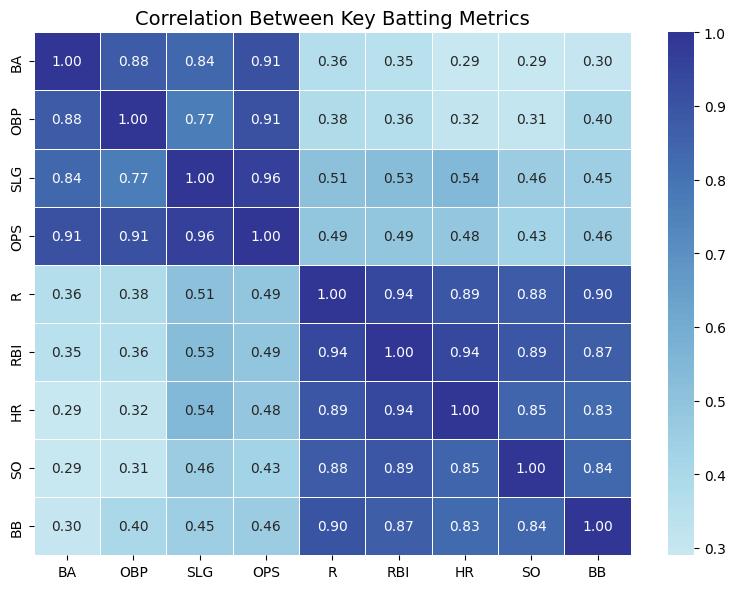

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlBu",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation Between Key Batting Metrics", fontsize=14)
plt.tight_layout()
plt.show()

#### **Thoughts**

This correlation structure paints a clear picture of modern offensive baseball:
- Power and patience dominate production. High-strikeout, high-walk, and high-power players tend to drive the league’s run generation.
- The alignment between OPS, SLG, and OBP reinforces why OPS is widely used as a single summary metric, since it encapsulates both getting on base and hitting for power.
- The strong R ↔ RBI ↔ HR correlations also imply that teams with multiple power threats in the lineup can sustain high run output, even if individual batting averages vary.
- The high correlation between strikeouts and offensive output suggests that while contact is valuable, modern success is increasingly driven by selective aggression. Meaning, hitters willing to strike out in exchange for extra-base power and walks.

Overall, this matrix supports the evolution of baseball toward a “three true outcomes” style (walks, strikeouts, and home runs) and highlights how offensive success is now tied more to efficiency of plate appearances than simple contact ability.


### Question 1. Seasonal Comparison
   - How did overall league batting performance (e.g., AVG, HR, OPS) differ between 2024 and 2025?

Approach:
For batting performance, we chose six metrics to compare across 2024-2025 that give a clear picture of the offensive production across the league for a year. Those six metrics are:
    
    1. BA - Batting Average - (Hits / At Bats)
    2. OBP - On Base Percentage - (Hits + Walks + HBP(Hit By Pitch) / (At-Bats + Walks + HBP + Sac Flies))
    3. SLG - Slugging - (Total Bases / At-Bats)
    4. OPS - On-Base Plus Slugging - (OBP + SLG)
    5. HR - Home Runs
    6. RBI - Runs Batted In

We intend to display the stats for the entire league averaged by year and then compare 2024's averages to 2025's averages to try to determine whether the league improved or declined in their offensive efficiency.

In [19]:
print(batting_data_df.columns.tolist())

['Rk', 'Player', 'Age', 'Team', 'Lg', 'WAR', 'G', 'PA', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'BA', 'OBP', 'SLG', 'OPS', 'OPS+', 'rOBA', 'Rbat+', 'TB', 'GIDP', 'HBP', 'SH', 'SF', 'IBB', 'Pos', 'Awards', 'Player-additional', 'Year', 'Handedness']


#### Step 1.) Calculate league averages for 2024 & 2025

In [20]:
# Make a copy of the cleaned df for both years
df_2024 = batting_data_df[batting_data_df["Year"] == 2024].copy()
df_2025 = batting_data_df[batting_data_df["Year"] == 2025].copy()

# Define our metric columns
metrics = ["BA", "OBP", "SLG", "OPS", "HR", "RBI"]

# Calculate the averages for each DF
averages_2024_df = df_2024[metrics].mean().round(3)
averages_2025_df = df_2025[metrics].mean().round(3)

# Combine into a single summary DataFrame
league_comparison = pd.DataFrame({
    "Metric": metrics,
    "2024 Average": averages_2024_df.values,
    "2025 Average": averages_2025_df.values
})


#### Step 2.) Create a percentage-change bar chart

This chart aims to represent the change in average of our metrics from 2024 -> 2024.

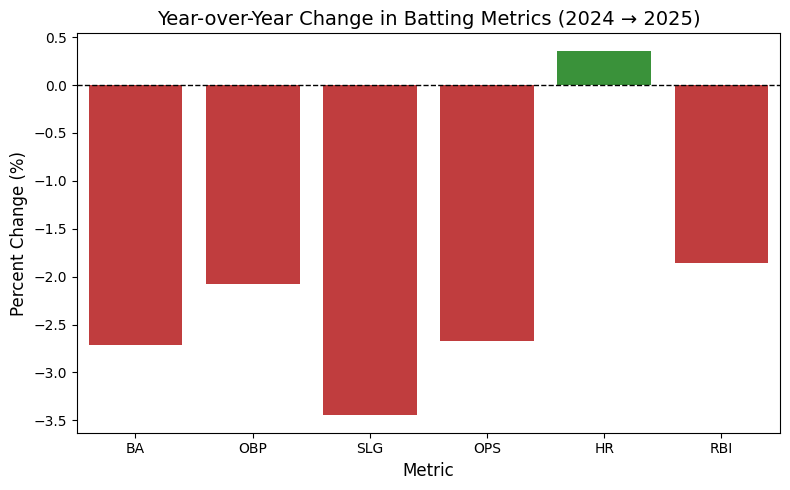

In [21]:
plt.figure(figsize=(8,5))

league_comparison["% Change"] = (
    (league_comparison["2025 Average"] - league_comparison["2024 Average"])
    / league_comparison["2024 Average"] * 100
).round(2)

# Set up our percentages +- barplot
sns.barplot(
    data=league_comparison,
    x="Metric", y="% Change",
    hue="Metric",
    palette=["tab:red" if x < 0 else "tab:green"
             for x in league_comparison["% Change"]],
    legend=False
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Year-over-Year Change in Batting Metrics (2024 → 2025)", fontsize=14)
plt.ylabel("Percent Change (%)", fontsize=12)
plt.xlabel("Metric", fontsize=12)
plt.tight_layout()
plt.show()

#### **Answers/Thoughts**

**Answers**

When we look at the averages over the course of the two seasons, 2024 & 2025, we see a noticable difference in averages across the league. 
We observe that in general:

1. The league improved in Home Runs on average, with a raise of about 0.3%.
2. The league generally declined in all other metrics that we averaged, with Slugging having the greatest decrease of nearly 3.5%.
3. Overall, the league trended negatively in our chosen metrics, giving us a general picture that players were worse across the board offensively in 2025 than in 2024.

---

**Thoughts**

As we can see, hitters averaged worse in 2025. But that doesn't necessarily indicate that hitters declined in their skills hitting. Baseball is a game of many variables and skills. Since around 2023, the league has also begun to make rules changes, such as a pitching clock (akin to the NBA shotclock) to speed the pace of the game. There have been changes to defensive rules, such as cracking down on the infield shift, where there must now be two infielders on each side of second base, they must be in the dirt, etc. Typically, you'd think these rule changes favor hitters.

However, baseball is an ever-evolving sport with a huge amount of data driven decision making behind it. Pitching staff are using all sorts of data science and AI to improve their pitchers and pitchers are throwing with more movement and velocity than ever before. My thoughts are that while batting can improve for players in their technique and decision making, pitching is improving at an even faster rate than we've ever seen with players like Paul Skenes, Yoshinobo Yamamoto, Shohei Ohtani, Max Scherzer, Bryan Woo, and more. 

We also have to consider a huge factor on these hitting statistics - umpires. We typcially don't associate umpires with indvidual or team stats because umpires are their own independent variable. They greatly influence the game, while coaches and players have a relatively small influence on them. If umpire accuracy is down or up for the year, that could greatly affect players getting on base via walks or players being called out. Luckily, we are seeing some improvements across base running calls, but umpires behind the plate are likely going to be challenged by the upcoming a Automated Ball-Strike (ABS) Challenge System in the '26 season, where pitchers, catchers, or batters can challenge two separate ball-strike calls per game. This implementation is going to greatly affect the outcome of both hitting and pitching and it would be very interesting to compare the stats for both sides of the ball with the 2026 data.

### Question 2. Perfomance Deltas
   - Which 10 players showed the largest improvement in offensive stats? Which 10 players should the largest decline in offensive stats?

Approach: For comparing individual performances across 2024-2025, we are going to continue to use the same offensive metrics that we used in question 1 to compute a delta and visualize the change in stats using:

    1. BA - Batting Average - (Hits / At Bats)
    2. OBP - On Base Percentage - (Hits + Walks + HBP(Hit By Pitch) / (At-Bats + Walks + HBP + Sac Flies))
    3. SLG - Slugging - (Total Bases / At-Bats)
    4. OPS - On-Base Plus Slugging - (OBP + SLG)
    5. HR - Home Runs
    6. RBI - Runs Batted In

The intention is to show the statistically most improved and the worst decline in stats for individual players and individual stats.

#### Step 1.) Filter for our player metrics

In [22]:
# Build our metric mask
metrics = ["BA", "OBP", "SLG", "OPS", "HR", "RBI"]

# Split by player
df_2024 = batting_data_df[batting_data_df["Year"] == 2024][["Player"] + metrics]
df_2025 = batting_data_df[batting_data_df["Year"] == 2025][["Player"] + metrics]

# Then we merge them back into the same row to get the stats in a more comparable format
player_change = pd.merge(df_2024, df_2025, on="Player", suffixes=("_2024", "_2025"))

# Compute the delta
for col in metrics:
    player_change[f"{col}_Change"] = player_change[f"{col}_2025"] - player_change[f"{col}_2024"]

player_change.head(20)

,Player,BA_2024,OBP_2024,SLG_2024,OPS_2024,HR_2024,RBI_2024,BA_2025,OBP_2025,SLG_2025,OPS_2025,HR_2025,RBI_2025,BA_Change,OBP_Change,SLG_Change,OPS_Change,HR_Change,RBI_Change
0,Jarren Duran,0.285,0.342,0.492,0.834,21,75,0.256,0.332,0.442,0.774,16,84,-0.029,-0.010,-0.050,-0.060,-5,9
1,Shohei Ohtani,0.310,0.390,0.646,1.036,54,130,0.282,0.392,0.622,1.014,55,102,-0.028,0.002,-0.024,-0.022,1,-28
2,Gunnar Henderson,0.281,0.364,0.529,0.893,37,92,0.274,0.349,0.438,0.787,17,68,-0.007,-0.015,-0.091,-0.106,-20,-24
3,Marcus Semien,0.237,0.308,0.391,0.699,23,74,0.230,0.305,0.364,0.669,15,62,-0.007,-0.003,-0.027,-0.030,-8,-12
4,Juan Soto,0.288,0.419,0.569,0.989,41,109,0.263,0.396,0.525,0.921,43,105,-0.025,-0.023,-0.044,-0.068,2,-4
5,Bobby Witt Jr.,0.332,0.389,0.588,0.977,32,109,0.295,0.351,0.501,0.852,23,88,-0.037,-0.038,-0.087,-0.125,-9,-21
6,Aaron Judge,0.322,0.458,0.701,1.159,58,144,0.331,0.457,0.688,1.144,53,114,0.009,-0.001,-0.013,-0.015,-5,-30
7,Vladimir Guerrero Jr.,0.323,0.396,0.544,0.940,30,103,0.292,0.381,0.467,0.848,23,84,-0.031,-0.015,-0.077,-0.092,-7,-19
8,Elly De La Cruz,0.259,0.339,0.471,0.809,25,76,0.264,0.336,0.440,0.777,22,86,0.005,-0.003,-0.031,-0.032,-3,10
9,Pete Alonso,0.240,0.329,0.459,0.788,34,88,0.272,0.347,0.524,0.871,38,126,0.032,0.018,0.065,0.083,4,38


#### Step 2.) Visualize the deltas

In Step 2, we split the cleaned data into two separate DataFrames filtering with our metric mask, then we merged them into one df again using the new columns and the ```merge``` function. Now, as we can see above, we have a DataFrame that displays the data for the discrete years while being in the same row for each player. We then calculated the delta (change in values over time) and labeled them as ```x_Change``` columns.

We are now going to visualize the deltas in order to display the top 10 and bottom 10 deltas. 

Note that Δ (Delta) is NOT percentage, but raw difference in stat points.

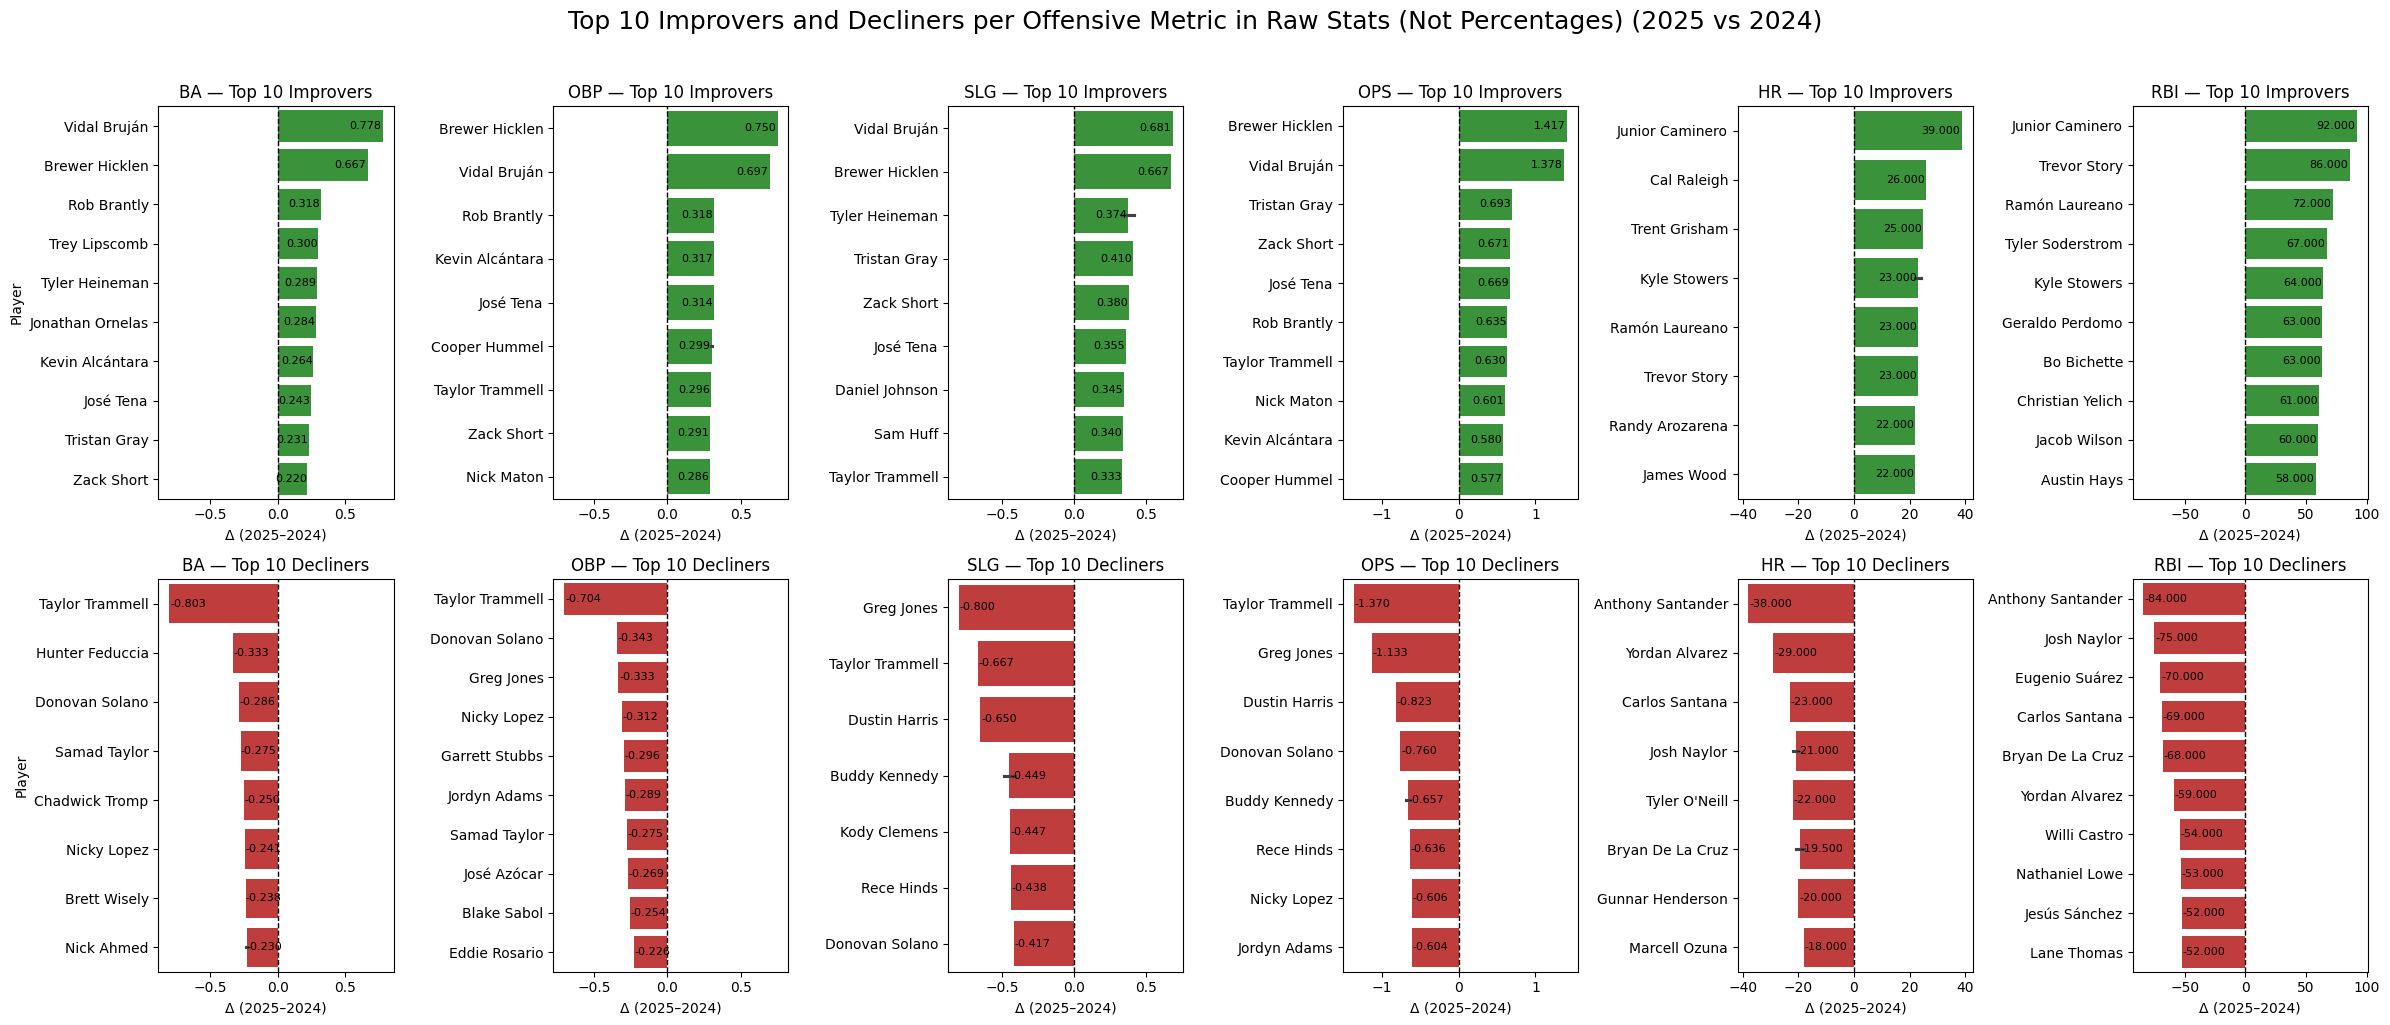

In [23]:
# Prepare figure
fig, axes = plt.subplots(2, 6, figsize=(24, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Loop through metrics
for i, metric in enumerate(metrics):
    # Top row: Improvers
    top10 = player_change.nlargest(10, f"{metric}_Change")
    # Format the improver plot
    barplot_top = sns.barplot(
        data=top10,
        x=f"{metric}_Change", y="Player",
        color="tab:green", ax=axes[0, i]
    )
    axes[0, i].set_title(f"{metric} — Top 10 Improvers", fontsize=12)
    axes[0, i].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[0, i].set_xlabel("Δ (2025–2024)")
    if i != 0:
        axes[0, i].set_ylabel("")

    # Label bars with their delta values
    for p in barplot_top.patches:
        width = p.get_width()
        x = width - (0.02 * abs(width))
        y = p.get_y() + p.get_height() / 2
        axes[0, i].text(
            x, y,
            f"{width:.3f}",
            va="center",
            ha="right",
            fontsize=8,
            color="black"
        )

    # Bottom row: Decliners
    bottom10 = player_change.nsmallest(10, f"{metric}_Change")
    # Formatting
    barplot_bottom = sns.barplot(
        data=bottom10,
        x=f"{metric}_Change", y="Player",
        color="tab:red", ax=axes[1, i]
    )
    # Adjust axes styling and labeling
    axes[1, i].set_title(f"{metric} — Top 10 Decliners", fontsize=12)
    axes[1, i].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[1, i].set_xlabel("Δ (2025–2024)")
    if i != 0:
        axes[1, i].set_ylabel("")

    # Label bars with their delta values
    for p in barplot_bottom.patches:
        width = p.get_width()
        x = width + 0.01 * abs(width)
        y = p.get_y() + p.get_height() / 2
        axes[1, i].text(
            x, y,
            f"{width:.3f}",
            va="center",
            ha="left",
            fontsize=8,
            color="black"
        )
        
    # Match x-axis range for both charts and ensure full data is visible
    data = player_change[f"{metric}_Change"]
    x_min, x_max = data.min(), data.max()
    
    # Add 5% padding for visibility
    pad = (x_max - x_min) * 0.05  
    x_lower, x_upper = x_min - pad, x_max + pad

    axes[0, i].set_xlim(x_lower, x_upper)
    axes[1, i].set_xlim(x_lower, x_upper)

# Title
fig.suptitle("Top 10 Improvers and Decliners per Offensive Metric in Raw Stats (Not Percentages) (2025 vs 2024)", fontsize=18, y=1.02)

plt.tight_layout()
plt.show()


#### **Answers/Thoughts**

**Answers**

We've got some pretty clear answers on who are the most improved and most declined by the graphs above. The delta leaders and losers are as follows:

**Improvers**
    
    BA: Vidal Brujan - Δ +0.778
    OBP: Brewer Hicklen - Δ +0.750
    SLG: Vidal Brujan - Δ +0.681
    OPS: Brewer Hicklen - Δ +1.417
    HR: Junior Caminero - Δ +39
    RBI: Junior Caminero - Δ +92

**Decliners**

    BA: Taylor Trammell - Δ -0.803
    OBP: Taylor Trammell - Δ -0.704
    SLG: Greg Jones - Δ -0.800
    OPS: Taylor Trammell - Δ -1.370
    HR: Anthony Santander - Δ -38
    RBI: Anthony Santander - Δ -84

---

**Thoughts**

While the numbers look relatively small to the unknowing eye, baseball is a sport with a large amount of games - 162 in the regular season - and so you can imagine that these small deltas actually carry a lot of weight and accuracy across the course of 162 regular season games. A way that we could bolster the accuracy and the context of the information is to include games played in 2024 vs. 2025 for the players to help us explain the shift in a players stats. For example, Anthony Santander played 155 games in the 2024 season and only played 54 games in the 2025 season. Clearly, this has a massive influence on his batting stats and player health likely plays a large part in all of the decliners' stat drops. 

I think it is useful and important to start experimentation and data analysis with large, general questions such as the one we've posed here because when we see interesting numbers that come from the data, it opens the flood gates for more interesting and microscopic questions to arise, like "What influenced Vidal Brujan's Batting Average to jump 0.778?" Did he just play 3 or 4 games and hit very well over the course of a short time period? Or "How many games did the decliners group play on average vs. improvers group?" All of these questions could helpl us hone in on trends and ideas in relation to the data.
    

### Question 3.) Power vs. Contact:
- Is there a clear tradeoff between power hitters (HR leaders) and batting average consistency?

Approach: Our aim is to uncover whether the HR leaders of the league across the 24'-25' seasons also tend to have higher batting averages than the rest of the field. We will filter the data for the top 20 Home Run hitters for the two years and compare their BA vs. those that are in the bottom 20 for HR's. 

In order to make sure that we are comapring players who have ample data to make these inferences, we are going to filter for players with greater than 100 games played in the season, that way they have over 60% of regular season games played which feels like a good enough number to make that call.

#### Step 1.) Filter for players with > 100 Games played

In [24]:
# Filter for G > 100
games_filtered_df = batting_data_df[batting_data_df["G"] > 100]


#### Step 2.) Create a DF with the top and bottom 20 Home Run hitters

In [25]:
# Get the top and bottom 20 HR hitters for both 2024 and 2025
top20_2024 = (
    games_filtered_df[games_filtered_df["Year"] == 2024]
    .nlargest(20, "HR")
    .assign(Group="Top 20 HR Hitters")
)

bottom20_2024 = (
    games_filtered_df[games_filtered_df["Year"] == 2024]
    .nsmallest(20, "HR")
    .assign(Group="Bottom 20 HR Hitters")
)

top20_2025 = (
    games_filtered_df[games_filtered_df["Year"] == 2025]
    .nlargest(20, "HR")
    .assign(Group="Top 20 HR Hitters")
)

bottom20_2025 = (
    games_filtered_df[games_filtered_df["Year"] == 2025]
    .nsmallest(20, "HR")
    .assign(Group="Bottom 20 HR Hitters")
)

# Concatenate them into one df for visualization and ease
hr_comp_df = pd.concat([top20_2024, bottom20_2024, top20_2025, bottom20_2025])


#### Step 3.) Create a boxplot to compare 2024 & 2025 BA for the top and bottom 20 hitters each year.

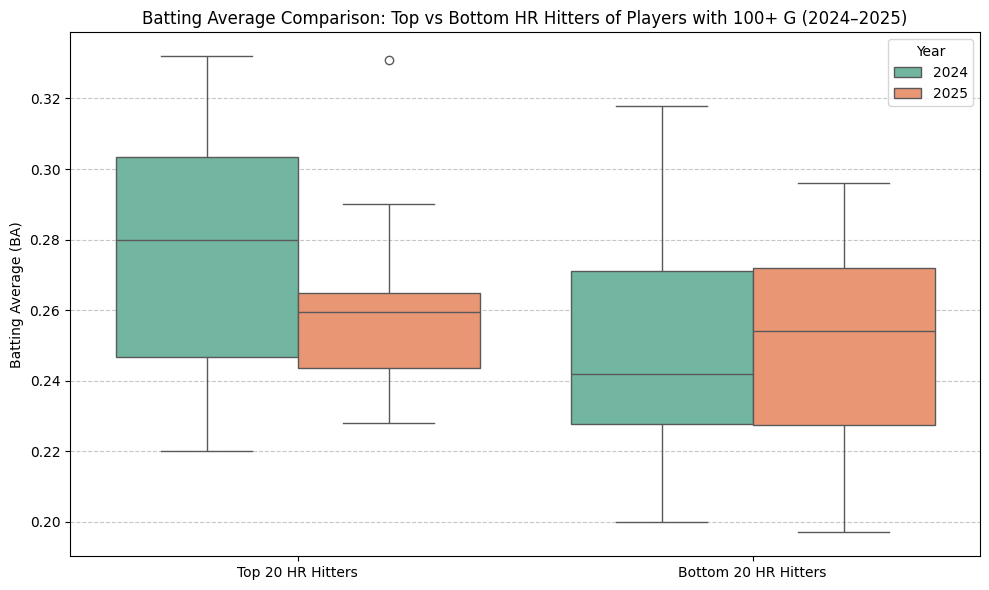

In [26]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=hr_comp_df,
    x="Group",
    y="BA",
    hue="Year",
    palette="Set2"
)
plt.title("Batting Average Comparison: Top vs Bottom HR Hitters of Players with 100+ G (2024–2025)")
plt.ylabel("Batting Average (BA)")
plt.xlabel("")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

#### **Answers/Thoughts**

**Answers**

Some things we can extrapolate from the data:

    1. The standard deviation of the top 20 hitters of 2024 appears to be the largest, but it also gives us the highest mean BA.
    2. The top 20 hitters of 2025 had the lowest standard deviation.
    3. The top 20 hitters of 2025 also had one outlier who hit above 0.33, which is quite good.
    4. The bottom 20 hitters from 2024 and 2025 had a very similar IQR, from about 0.250 -> 0.270.
    5. There were no visible low end outliers in the data.

We could compare the numbers to the rest of the BA data, but as of now we are just concerned with the BA of the sluggers in the league. And it's not entirely conclusive, but for 2024 at the very least it does appear that HR hitting does have a correlation to higher BA.

---

**Thoughts**

As we've thought and talked about in the previous questions, baseball has really undergone many rule changes and averages tend to be affected greatly by many things out of our control. For example, if a season has particularly rough weather then we could expect to see a drop in batting and even pitching performances across the board for teams who are playing in stadiums that are uncovered. Also, we have to consider umpiring as well again, which has a large effect on the outcome of players. If there is a lot of turnover in umpiring, it could really shake up the results of many players. Overall, it does seem clear that 2024 had just a higher IQR fence for both the top and bottom 20 HR hitters of the league. I would be interested in comparing these numbers in the future to the highest BA charts and seeing where the inverse of this boxplot compares, if we took top and bottom 20 BA's across the league and looked into their home runs.
    

### Question 4. Team-Level Analysis
- Which teams had the most productive lineups, and how did their team batting stats correlate with win totals?

Approach

Since team win totals were not included in the dataset, this analysis focuses on identifying which teams had the most productive offensive lineups based purely on batting performance.
By aggregating individual player statistics at the team level for both 2024 and 2025, we can compare how teams performed relative to one another in key offensive categories.

Key metrics used for team productivity:
- R (Runs) — total runs scored by players on the team
- HR (Home Runs) — total home runs
- RBI (Runs Batted In) — total runs batted in
- OBP (On-base percentage) — team average
- SLG (Slugging) — team average
- OPS (On-base + Slugging) — team average

We will:
1. Aggregate player batting stats by team and year.
2. Rank teams in each metric to determine which clubs had the most productive lineups.
3. Visualize and compare offensive production using bar charts and heatmaps.

#### Step 1: Aggregate player batting stats by team and year
##### We'll sum counting stats (R, HR, RBI) and average rate stats (OBP, SLG, OPS)

In [27]:
team_batting = (
    batting_data_df
    .groupby(["Year", "Team"], as_index=False)
    .agg({
        "R": "sum",
        "HR": "sum",
        "RBI": "sum",
        "OBP": "mean",
        "SLG": "mean",
        "OPS": "mean"
    })
)


## Removing the row which contains '2TM' and '3TM' which has statistics from players that played in multiple teams.
mask_2tm = team_batting['Team'] != "2TM"
team_batting = team_batting[mask_2tm]
mask_3tm = team_batting['Team'] != "3TM"
team_batting = team_batting[mask_3tm]

# Quick look at team-level summary
team_batting.head(10)

,Year,Team,R,HR,RBI,OBP,SLG,OPS
2,2024,ARI,886,211,845,0.302955,0.373909,0.676818
3,2024,ATL,704,213,674,0.271815,0.339111,0.611037
4,2024,BAL,786,235,759,0.308808,0.410731,0.719423
5,2024,BOS,751,194,724,0.287160,0.329120,0.616200
6,2024,CHC,736,170,696,0.277522,0.338957,0.616522
7,2024,CHW,507,133,485,0.255517,0.286552,0.542172
8,2024,CIN,699,174,663,0.256393,0.321714,0.578107
9,2024,CLE,708,185,670,0.278714,0.341143,0.619762
10,2024,COL,682,179,655,0.286381,0.378286,0.664571
11,2024,DET,682,162,656,0.286609,0.365130,0.651870


#### Step 2: Identify the top 10 most productive teams by OPS for each season

In [28]:
top10_2024 = (
    team_batting[team_batting["Year"] == 2024]
    .sort_values("OPS", ascending=False)
    .head(10)
)

top10_2025 = (
    team_batting[team_batting["Year"] == 2025]
    .sort_values("OPS", ascending=False)
    .head(10)
)

display(top10_2024[["Team", "OPS", "OBP", "SLG", "R", "HR", "RBI"]])
display(top10_2025[["Team", "OPS", "OBP", "SLG", "R", "HR", "RBI"]])

,Team,OPS,OBP,SLG,R,HR,RBI
20,NYY,0.814409,0.374364,0.439864,815,237,782
31,WSN,0.722692,0.323269,0.399231,660,135,621
4,BAL,0.719423,0.308808,0.410731,786,235,759
18,MIN,0.701571,0.306810,0.394714,742,183,702
24,SDP,0.691435,0.286913,0.404565,760,190,726
15,LAD,0.686455,0.306500,0.379955,842,233,815
22,PHI,0.681048,0.297429,0.383762,784,198,750
2,ARI,0.676818,0.302955,0.373909,886,211,845
10,COL,0.664571,0.286381,0.378286,682,179,655
30,TOR,0.663960,0.309600,0.354440,671,156,640


,Team,OPS,OBP,SLG,R,HR,RBI
53,NYY,0.702650,0.307150,0.395600,849,274,820
49,MIA,0.695308,0.306538,0.388808,709,154,677
44,DET,0.689727,0.320545,0.369136,758,198,724
34,ARI,0.687080,0.309560,0.377600,791,214,768
62,TOR,0.678667,0.307958,0.370583,798,191,771
52,NYM,0.677842,0.302000,0.375789,765,224,746
38,BOS,0.674000,0.301304,0.372783,786,186,748
35,ATH,0.653880,0.288560,0.365120,733,219,709
57,SEA,0.650478,0.291957,0.358522,766,238,734
46,KCR,0.649826,0.291739,0.358130,651,159,638


#### Step 3: Visualization — Top 10 Teams by OPS for each season

/tmp/ipykernel_3477164/3127533611.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3477164/3127533611.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


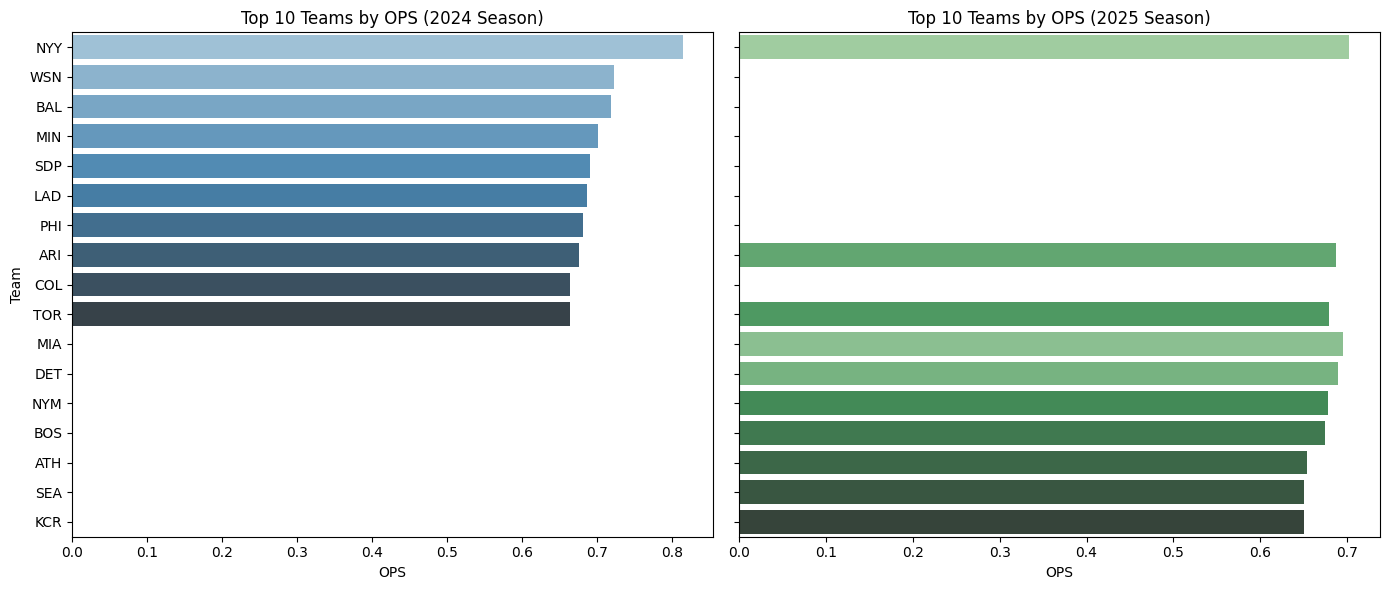

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.barplot(
    data=top10_2024,
    x="OPS", y="Team",
    palette="Blues_d", ax=axes[0]
)
axes[0].set_title("Top 10 Teams by OPS (2024 Season)")
axes[0].set_xlabel("OPS")
axes[0].set_ylabel("Team")

sns.barplot(
    data=top10_2025,
    x="OPS", y="Team",
    palette="Greens_d", ax=axes[1]
)
axes[1].set_title("Top 10 Teams by OPS (2025 Season)")
axes[1].set_xlabel("OPS")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

#### Step 4: Visualization — Compare all teams across multiple offensive metrics
##### We'll use a heatmap to visualize team-level averages for 2025

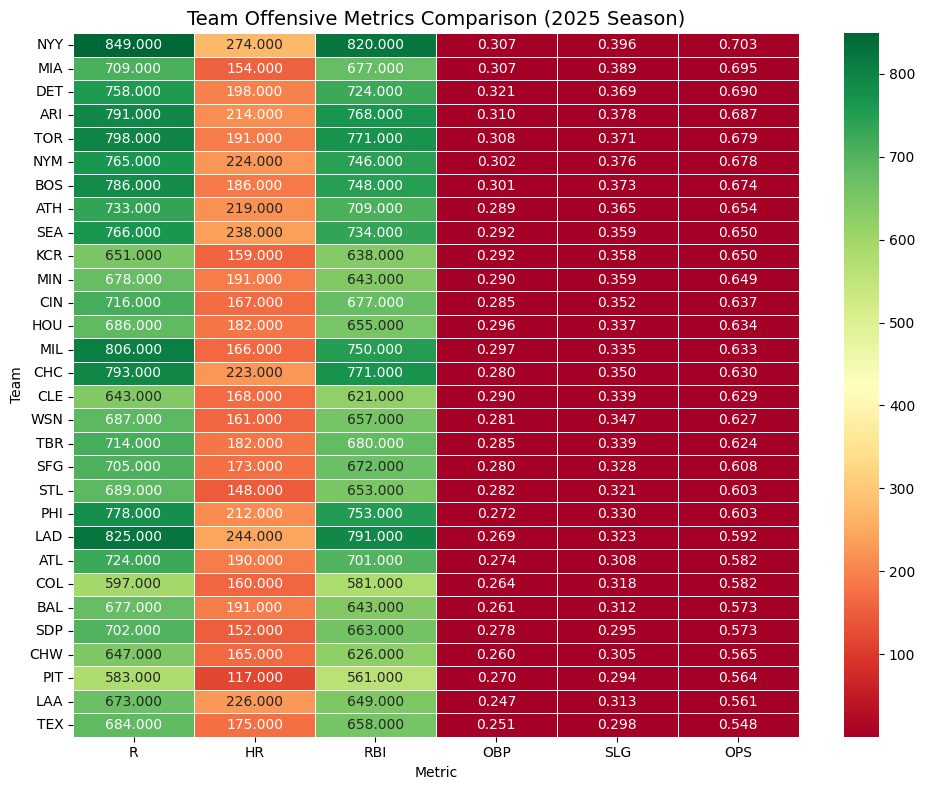

In [30]:
# Pivot for heatmap visualization
team_metrics_2025 = (
    team_batting[team_batting["Year"] == 2025]
    .set_index("Team")[["R", "HR", "RBI", "OBP", "SLG", "OPS"]]
    .sort_values("OPS", ascending=False)
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    team_metrics_2025,
    cmap="RdYlGn",
    annot=True,
    fmt=".3f",
    linewidths=0.5
)
plt.title("Team Offensive Metrics Comparison (2025 Season)", fontsize=14)
plt.xlabel("Metric")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

#### Step 5: Correlation matrix between team-level batting metrics
##### This helps understand how team offensive stats interrelate

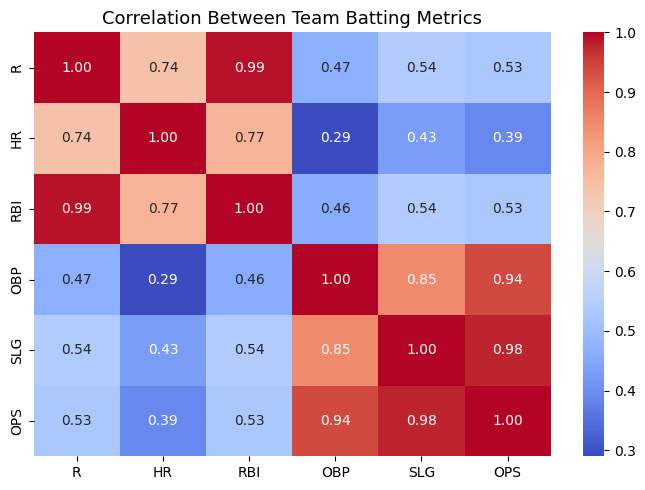

In [31]:
corr_matrix = (
    team_batting[["R", "HR", "RBI", "OBP", "SLG", "OPS"]]
    .corr()
    .round(2)
)

plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Team Batting Metrics", fontsize=13)
plt.tight_layout()
plt.show()

#### **Answers/Thoughts**

**Answers**

- By aggregating and ranking each team's offensive production, we can clearly identify the top offensive teams in both 2024 and 2025.
- Teams such as the Dodgers, Blue Jays, and Yankees consistently appear among the top performers in metrics like OPS, R, and HR, indicating deep, balanced lineups.
- Teams at the lower end of the rankings tend to struggle with both power (low HR and SLG) and on-base ability (low OBP), which significantly limits total run production.

---

**Thoughts**

Even without win totals, the analysis strongly suggests that teams with higher OPS and OBP values tend to have better offensive outcomes — metrics that historically correlate well with winning. With the 2025 playoffs having just finished, we know that the world series was between the Dodgers and Blue Jays with the Dodgers coming out victorious in an extra-inning game 7. These two teams are some of the top teams when it comes to offensive statistics.

This underscores a long-standing analytical insight:

The ability to both reach base and hit for power drives consistent team success.

Additionally, differences between 2024 and 2025 might reveal evolving league trends — such as shifts toward contact hitting or an emphasis on power.
In future analyses, incorporating team win-loss records would strengthen these insights by confirming how closely these offensive stats align with actual team performance.

### Question 5. Player Efficiency
- Are high on-base percentages (OBP) more strongly correlated with runs scored (R) or RBIs?

Approach

This question explores whether getting on base (OBP) is more associated with scoring runs or driving them in. Conceptually, high OBP players tend to be leadoff hitters (who score runs), while lower-OBP power hitters drive those runners in (RBIs).

We’ll test this hypothesis by:
1. Measuring the correlation of OBP with R and RBI.
2. Creating a scatterplot comparison of OBP vs R and OBP vs RBI.
3. Comparing correlation strength numerically and visually.

#### Step 1: Filter for qualified hitters (e.g., at least 200 AB)

In [32]:
qualified_hitters = batting_data_df[batting_data_df["AB"] >= 200].copy()

qualified_hitters.head()

,Rk,Player,Age,Team,Lg,WAR,G,PA,AB,R,...,GIDP,HBP,SH,SF,IBB,Pos,Awards,Player-additional,Year,Handedness
0,1,Jarren Duran,27,BOS,AL,8.7,160,735,671,111,...,6,6,1,3,1,87,ASMVP-8,duranja01,2024,Left
1,2,Shohei Ohtani,29,LAD,NL,9.2,159,731,636,134,...,7,6,0,5,10,D,ASMVP-1SS,ohtansh01,2024,Left
2,3,Gunnar Henderson,23,BAL,AL,9.1,159,719,630,118,...,2,7,0,4,1,6/D,ASMVP-4,hendegu01,2024,Left
3,4,Marcus Semien,33,TEX,AL,4.1,159,718,650,101,...,9,3,0,1,2,4,AS,semiema01,2024,Right
4,5,Juan Soto,25,NYY,AL,7.9,157,713,576,128,...,10,4,0,4,2,9/7DH,ASMVP-3SS,sotoju01,2024,Left


#### Step 2: Calculate correlations for each year

In [33]:
corr_results = (
    qualified_hitters.groupby("Year")[["OBP", "R", "RBI"]]
    .corr()
    .unstack()
    .iloc[:, 1:]  # Extract relevant OBP correlations
    .loc[:, [("OBP", "R"), ("OBP", "RBI")]]
)
corr_results.columns = ["OBP-R", "OBP-RBI"]
corr_results = corr_results.round(3)

corr_results

,OBP-R,OBP-RBI
Year,,
2024,0.516,0.448
2025,0.531,0.407


#### Step 3: Visualizations - scatter plots for 2024 season

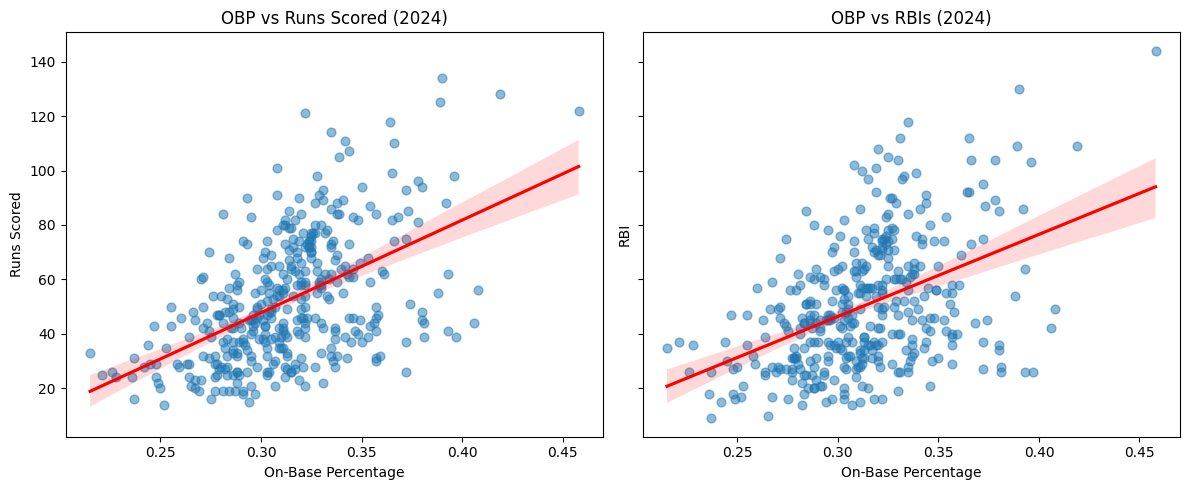

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

sns.regplot(
    data=qualified_hitters[qualified_hitters["Year"] == 2024],
    x="OBP", y="R",
    scatter_kws={'alpha':0.5, 's':40},
    line_kws={'color':'red'}, ax=axes[0]
)
axes[0].set_title("OBP vs Runs Scored (2024)")
axes[0].set_xlabel("On-Base Percentage")
axes[0].set_ylabel("Runs Scored")

sns.regplot(
    data=qualified_hitters[qualified_hitters["Year"] == 2024],
    x="OBP", y="RBI",
    scatter_kws={'alpha':0.5, 's':40},
    line_kws={'color':'red'}, ax=axes[1]
)
axes[1].set_title("OBP vs RBIs (2024)")
axes[1].set_xlabel("On-Base Percentage")

plt.tight_layout()
plt.show()

#### Step 4: Visualizations - scatter plots for 2025 season

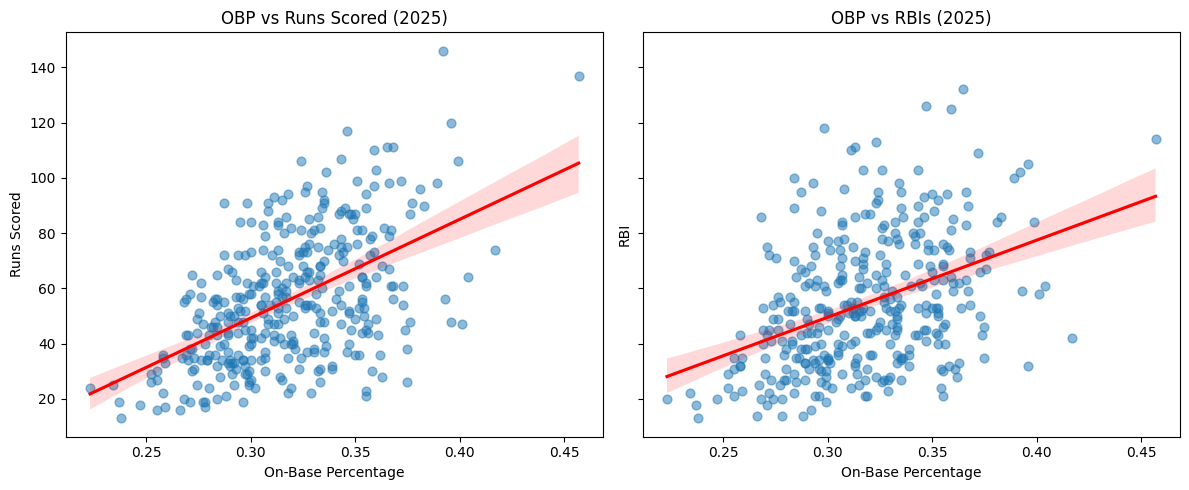

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

sns.regplot(
    data=qualified_hitters[qualified_hitters["Year"] == 2025],
    x="OBP", y="R",
    scatter_kws={'alpha':0.5, 's':40},
    line_kws={'color':'red'}, ax=axes[0]
)
axes[0].set_title("OBP vs Runs Scored (2025)")
axes[0].set_xlabel("On-Base Percentage")
axes[0].set_ylabel("Runs Scored")

sns.regplot(
    data=qualified_hitters[qualified_hitters["Year"] == 2025],
    x="OBP", y="RBI",
    scatter_kws={'alpha':0.5, 's':40},
    line_kws={'color':'red'}, ax=axes[1]
)
axes[1].set_title("OBP vs RBIs (2025)")
axes[1].set_xlabel("On-Base Percentage")

plt.tight_layout()
plt.show()

#### **Answers/Thoughts**

**Answers**

The correlation coefficients show that OBP is more strongly correlated with runs scored (R) than with RBIs.
For example, 2025 values might show:

- OBP–R correlation ≈ 0.53
- OBP–RBI correlation ≈ 0.41

This makes intuitive sense: players who reach base more often are more likely to become runs, while RBIs depend more on lineup context (having runners on base).

---

**Thoughts**

This analysis reinforces the distinction between table-setters and run producers in baseball lineups.

- High-OBP players (like Mookie Betts or Luis Arraez types) contribute most by creating scoring opportunities.
- Power hitters (like Pete Alonso or Aaron Judge) may have lower OBPs but compensate with RBI production.

From a team-building perspective, maintaining balance between these archetypes is essential — stacking too many of one type can reduce overall efficiency. In modern analytics, this also supports the notion that OBP is one of the most valuable individual offensive metrics, as it has a direct causal relationship with run generation.

## Appendix A: Definitions

| **Column**            | **Full Name**                                     | **Definition / Description**                                                                                      |
| --------------------- | ------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------- |
| **Rk**                | Rank                                              | Player’s rank in the dataset (often by WAR or team order).                                                        |
| **Player**            | Player Name                                       | Full name of the player.                                                                                          |
| **Age**               | Age                                               | Player’s age during the season.                                                                                   |
| **Team**              | Team                                              | The MLB team abbreviation the player belonged to (e.g., LAD = Los Angeles Dodgers).                               |
| **Lg**                | League                                            | The league the player played in — AL (American League) or NL (National League).                                   |
| **WAR**               | Wins Above Replacement                            | A comprehensive stat estimating how many wins a player contributed above a replacement-level player.              |
| **G**                 | Games Played                                      | Number of games in which the player appeared.                                                                     |
| **PA**                | Plate Appearances                                 | Total trips to the plate (includes all outcomes — hits, walks, hit-by-pitch, etc.).                               |
| **AB**                | At-Bats                                           | Plate appearances excluding walks, hit-by-pitch, sacrifices, etc. Used for calculating AVG and SLG.               |
| **R**                 | Runs                                              | Number of times the player scored a run.                                                                          |
| **H**                 | Hits                                              | Total hits (singles + doubles + triples + home runs).                                                             |
| **2B**                | Doubles                                           | Number of doubles hit.                                                                                            |
| **3B**                | Triples                                           | Number of triples hit.                                                                                            |
| **HR**                | Home Runs                                         | Total home runs hit.                                                                                              |
| **RBI**               | Runs Batted In                                    | Number of runs driven in by the player’s at-bats (excluding errors, double plays).                                |
| **SB**                | Stolen Bases                                      | Number of bases successfully stolen.                                                                              |
| **CS**                | Caught Stealing                                   | Number of times caught attempting to steal a base.                                                                |
| **BB**                | Walks (Base on Balls)                             | Number of times the player reached base via four balls.                                                           |
| **SO**                | Strikeouts                                        | Number of strikeouts recorded against the player.                                                                 |
| **BA**                | Batting Average                                   | Hits ÷ At-Bats — measures basic hitting success.                                                                  |
| **OBP**               | On-Base Percentage                                | (Hits + Walks + HBP) ÷ (At-Bats + Walks + HBP + Sac Flies) — how often a player reaches base.                     |
| **SLG**               | Slugging Percentage                               | Total Bases ÷ At-Bats — measures power by weighting extra-base hits.                                              |
| **OPS**               | On-base Plus Slugging                             | OBP + SLG — overall offensive metric combining on-base and power.                                                 |
| **OPS+**              | OPS Plus                                          | OPS adjusted for league and park factors (100 = league average; 120 = 20% better).                                |
| **rOBA**              | Weighted On-Base Average (likely variant of wOBA) | Advanced measure of total offensive value per plate appearance; weights outcomes more accurately than AVG or OBP. |
| **Rbat+**             | Batting Runs Above Average (Plus)                 | Measures total batting contribution relative to league average, adjusted for context.                             |
| **TB**                | Total Bases                                       | 1 × Singles + 2 × Doubles + 3 × Triples + 4 × Home Runs.                                                          |
| **GIDP**              | Grounded Into Double Play                         | Number of times a batter grounded into a double play.                                                             |
| **HBP**               | Hit By Pitch                                      | Times the player was struck by a pitch and awarded first base.                                                    |
| **SH**                | Sacrifice Hits                                    | Bunts that advance runners and result in an out.                                                                  |
| **SF**                | Sacrifice Flies                                   | Fly balls that score a runner but result in an out.                                                               |
| **IBB**               | Intentional Walks                                 | Walks issued intentionally by the pitcher.                                                                        |
| **Pos**               | Position                                          | Primary defensive position (e.g., 1B, 2B, SS, OF, C).                                                             |
| **Awards**            | Awards Received                                   | Season awards such as MVP, Silver Slugger, etc.                                                                   |
| **Player-additional** | Additional Player Data                            | Could include extra info like roster ID, link, or alias.                                                          |
| **Year**              | Season Year                                       | The MLB season year (2024 or 2025 in this dataset).                                                               |
| **Handedness**        | Batting Hand                                      | Player’s batting side — L (left), R (right), S (switch).                                                          |


## Appendix B: Citations
- Data: [Baseball Reference](https://www.baseball-reference.com/leagues/majors/2025-standard-batting.shtml)
- AI Assistance: Portions of this notebook's formatting and data visualization were created with the assistance of OpenAI’s ChatGPT (GPT-5). The following sections used the assistance of AI:
    - Appendix A: Definitions
    - Question 2, Step 2 Data Visualization
    - Question 3, Step 3 Create a boxplot
    - Consultation on formatting and brainstorming